# CIS 2267 - Assignment 2 - Pandas

Use the Department of Labor's Civilian Labor Force Level data perform these tasks and answer these questions.

https://www.bls.gov/data/#unemployment

1. Import the data file.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
clf_df = pd.read_csv("CivilianLaborForce.csv")
clf_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1948,60095,60524,60070,60677,59972,60957,61181,60806,60815,60646,60702,61169
1,1949,60771,61057,61073,61007,61259,60948,61301,61590,61633,62185,62005,61908
2,1950,61661,61687,61604,62158,62083,62419,62121,62596,62349,62428,62286,62068
3,1951,61941,61778,62526,61808,62044,61615,62106,61927,61780,62204,62014,62457
4,1952,62432,62419,61721,61720,62058,62103,61962,61877,62457,61971,62491,62621


2. Describe the data.  What is in the file?  How many years' worth of data are there?

In [3]:
print('What is in the file?\n\n', clf_df.values)

print("\nThe other attributes:")
print("=> Index:  ", clf_df.index)
print("=> Columns:", clf_df.columns)
print("=> Size:   ", clf_df.size)
print("=> Shape:  ", clf_df.shape)

What is in the file?

 [[1948 '60095' 60524 ... '60646' '60702' '61169']
 [1949 '60771' 61057 ... '62185' '62005' '61908']
 [1950 '61661' 61687 ... '62428' '62286' '62068']
 ...
 [2024 '167308(1)' 167569 ... '168395' '168248' '168506']
 [2025 '170696(1)' 170441 ... '-(9)' '171541' '171495']
 [2026 '170465(12)' 170483 ... ' ' ' ' ' ']]

The other attributes:
=> Index:   RangeIndex(start=0, stop=79, step=1)
=> Columns: Index(['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep',
       'Oct', 'Nov', 'Dec'],
      dtype='object')
=> Size:    1027
=> Shape:   (79, 13)


In [4]:
print("Data overview:")
clf_df.info()

Data overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Year    79 non-null     int64 
 1   Jan     79 non-null     object
 2   Feb     79 non-null     int64 
 3   Mar     79 non-null     int64 
 4   Apr     79 non-null     int64 
 5   May     79 non-null     int64 
 6   Jun     79 non-null     int64 
 7   Jul     79 non-null     int64 
 8   Aug     79 non-null     int64 
 9   Sep     79 non-null     object
 10  Oct     79 non-null     object
 11  Nov     79 non-null     object
 12  Dec     79 non-null     object
dtypes: int64(8), object(5)
memory usage: 8.1+ KB


In [5]:
# Data Cleaning and Type Conversion
months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun' , 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

for col in months:
    # Delete footnotes 
    clf_df[col] = clf_df[col].astype(str).replace(r'\(\d+\)', '', regex = True).str.strip()

    # Convert to numeric (float)
    clf_df[col] = pd.to_numeric(clf_df[col], errors = 'coerce')
    
print("Data overview:")
clf_df.info()

print('\nDescriptive statistics:')
clf_df.describe()

Data overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Year    79 non-null     int64  
 1   Jan     79 non-null     int64  
 2   Feb     79 non-null     int64  
 3   Mar     79 non-null     int64  
 4   Apr     79 non-null     int64  
 5   May     79 non-null     int64  
 6   Jun     79 non-null     int64  
 7   Jul     79 non-null     int64  
 8   Aug     79 non-null     int64  
 9   Sep     78 non-null     float64
 10  Oct     77 non-null     float64
 11  Nov     78 non-null     float64
 12  Dec     78 non-null     float64
dtypes: float64(4), int64(9)
memory usage: 8.1 KB

Descriptive statistics:


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
count,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,79.000000,78.000000,77.000000,78.000000,78.000000
mean,1987.000000,115099.822785,115234.506329,115307.063291,115366.936709,115491.544304,115608.202532,115735.810127,115855.012658,115272.692308,114650.454545,115533.205128,115607.782051
std,22.949219,36723.843301,36717.192327,36706.658644,36563.289941,36592.914709,36595.742643,36571.510331,36612.323199,36338.438318,35989.409145,36355.851941,36332.730511
min,1948.000000,60095.000000,60524.000000,60070.000000,60677.000000,59972.000000,60948.000000,61181.000000,60806.000000,60815.000000,60646.000000,60702.000000,61169.000000
25%,1967.500000,77108.500000,77375.500000,77292.000000,77523.500000,77810.000000,78195.000000,78217.000000,78261.500000,78073.500000,78194.000000,78445.500000,78734.000000
50%,1987.000000,118845.000000,119122.000000,119270.000000,119336.000000,120008.000000,119644.000000,119902.000000,120318.000000,119203.000000,118516.000000,119587.000000,119670.000000
75%,2006.500000,151679.000000,151812.000000,151932.000000,151658.000000,151869.500000,152197.500000,152215.500000,152232.500000,151235.000000,150001.000000,151820.750000,152056.500000
max,2026.000000,170696.000000,170483.000000,170641.000000,171054.000000,170492.000000,170380.000000,170412.000000,170750.000000,171261.000000,168395.000000,171541.000000,171495.000000


In [6]:
min_year = clf_df.Year.min();
max_year = clf_df.Year.max();
total_years = len(clf_df)
print(f"File contains data from {min_year} to {max_year}")
print(f"Total years: {total_years}")

File contains data from 1948 to 2026
Total years: 79


_The file contains monthly Civilian Labor Force data spanning 79 years (from 1948 through 2026) across 13 columns (Year and 12 months, January to December)._

3. The numbers in this file are in thousands, so multiply everything by 1000 to get the actual number of people.

In [7]:
clf_df[months] = clf_df[months] * 1000
clf_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1948,60095000,60524000,60070000,60677000,59972000,60957000,61181000,60806000,60815000.0,60646000.0,60702000.0,61169000.0
1,1949,60771000,61057000,61073000,61007000,61259000,60948000,61301000,61590000,61633000.0,62185000.0,62005000.0,61908000.0
2,1950,61661000,61687000,61604000,62158000,62083000,62419000,62121000,62596000,62349000.0,62428000.0,62286000.0,62068000.0
3,1951,61941000,61778000,62526000,61808000,62044000,61615000,62106000,61927000,61780000.0,62204000.0,62014000.0,62457000.0
4,1952,62432000,62419000,61721000,61720000,62058000,62103000,61962000,61877000,62457000.0,61971000.0,62491000.0,62621000.0


4. What was the civilian labor force size in 1961?  What was it in 2021?

In [8]:
# Filter rows for target years using query
selected_df = clf_df.query('Year in (1961, 2021)')
display(selected_df)

# Calculate annual averages across monthly columns (axis=1) and cast to int
row_means = selected_df[months].mean(axis=1).round().astype(int)

# Display rounded annual averages with thousands separators
print(f"Average for 1961 Year: {row_means.values[0]:,} individuals")
print(f"Average for 2021 Year: {row_means.values[1]:,} individuals")

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
13,1961,70447000,70420000,70703000,70267000,70452000,70878000,70536000,70534000,70217000.0,70492000.0,70376000.0,70077000.0
73,2021,160081000,160248000,160439000,160799000,160806000,161202000,161543000,161527000,161454000.0,161736000.0,162243000.0,162466000.0


Average for 1961 Year: 70,449,917 individuals
Average for 2021 Year: 161,212,000 individuals


_Between 1961 and 2021, the U.S. civilian labor force more than doubled_

5. Write a short loop where the user enters a year and the program displays the labor force for that year.  End the loop if the user enters a year for which there is no data.

In [9]:
while True: 
    # min_year and max_year found in #2
    input_value = input(f"Enter a year (from {min_year} through {max_year}): ").strip()

    # Check if input is a valid number and exists in the dataset
    if not input_value.isdigit() or int(input_value) not in clf_df.Year.values:
        print(f"\nYear {input_value} is not in the dataset or input is invalid")
        break

    year = int(input_value)
    
    # Filter row for target years using loc
    selected_df = clf_df.loc[clf_df.Year == year]
    display(selected_df)
    
    # Calculate annual average across monthly columns (axis=1) and cast to int
    avg_value = int(round(selected_df[months].mean(axis=1).values[0]))

    # Display rounded annual average with thousands separators
    print(f"Average for {year} Year: {avg_value:,} individuals\n")    

Enter a year (from 1948 through 2026):  1948


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1948,60095000,60524000,60070000,60677000,59972000,60957000,61181000,60806000,60815000.0,60646000.0,60702000.0,61169000.0


Average for 1948 Year: 60,634,500 individuals



Enter a year (from 1948 through 2026):  2026


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
78,2026,170465000,170483000,170087000,169995000,170078000,169358000,169094000,169777000,NaN,NaN,NaN,NaN


...

Enter a year (from 1948 through 2026):  1961


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
13,1961,70447000,70420000,70703000,70267000,70452000,70878000,70536000,70534000,70217000.0,70492000.0,70376000.0,70077000.0


Average for 1961 Year: 70,449,917 individuals



Enter a year (from 1948 through 2026):  1947



Year 1947 is not in the dataset or input is invalid


6. Calculate an annual value column by averaging the January-December numbers.

In [10]:
# Compute Annual Average Column
clf_df['Annual'] = clf_df[months].mean(axis=1).round()
clf_df.tail()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
74,2022,163614000,163978000,164271000,163847000,164372000,164059000,164076000,164653000,164561000.0,164620000.0,164402000.0,164983000.0,164286333.0
75,2023,165943000,166443000,166707000,166674000,166896000,166958000,167169000,167760000,167725000.0,167661000.0,168090000.0,167388000.0,167117833.0
76,2024,167308000,167569000,167983000,167923000,167807000,168034000,168395000,168492000,168662000.0,168395000.0,168248000.0,168506000.0,168110167.0
77,2025,170696000,170441000,170641000,171054000,170492000,170380000,170412000,170750000,171261000.0,NaN,171541000.0,171495000.0,170833000.0
78,2026,170465000,170483000,170087000,169995000,170078000,169358000,169094000,169777000,NaN,NaN,NaN,NaN,169917125.0


7. Set the index for the DataFrame.

In [11]:
# Validate that each calendar year is unique
clf_df = clf_df.set_index('Year', verify_integrity = True)
clf_df.head()

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
Year,,,,,,,,,,,,,
1948,60095000,60524000,60070000,60677000,59972000,60957000,61181000,60806000,60815000.0,60646000.0,60702000.0,61169000.0,60634500.0
1949,60771000,61057000,61073000,61007000,61259000,60948000,61301000,61590000,61633000.0,62185000.0,62005000.0,61908000.0,61394750.0
1950,61661000,61687000,61604000,62158000,62083000,62419000,62121000,62596000,62349000.0,62428000.0,62286000.0,62068000.0,62121667.0
1951,61941000,61778000,62526000,61808000,62044000,61615000,62106000,61927000,61780000.0,62204000.0,62014000.0,62457000.0,62016667.0
1952,62432000,62419000,61721000,61720000,62058000,62103000,61962000,61877000,62457000.0,61971000.0,62491000.0,62621000.0,62152667.0


8. Save the DataFrame in a pickle file.

In [12]:
clf_df.to_pickle('CivilianLaborForce.pkl')
print("DataFrame saved successfully as CivilianLaborForce.pkl")

DataFrame saved successfully as CivilianLaborForce.pkl


9. Plot the DataFrame.

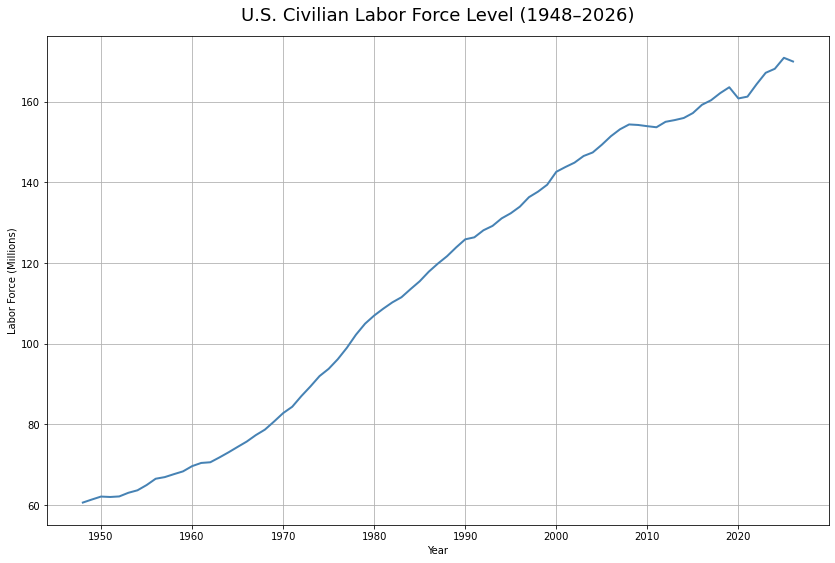

In [13]:
# A time-series line plot
ax = (clf_df['Annual'] / 1e6).plot(
    figsize=(14,9),      
    grid=True,
    linewidth=2,
    color='steelblue'
)

ax.set_title(
    "U.S. Civilian Labor Force Level (1948–2026)", fontsize=18, pad=15
)
ax.set_xlabel('Year')
ax.set_ylabel('Labor Force (Millions)')

plt.show()

In [14]:
# Reset the index to return 'Year' back to a regular column for subsequent grouping
clf_df.reset_index(inplace = True)
clf_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual
0,1948,60095000,60524000,60070000,60677000,59972000,60957000,61181000,60806000,60815000.0,60646000.0,60702000.0,61169000.0,60634500.0
1,1949,60771000,61057000,61073000,61007000,61259000,60948000,61301000,61590000,61633000.0,62185000.0,62005000.0,61908000.0,61394750.0
2,1950,61661000,61687000,61604000,62158000,62083000,62419000,62121000,62596000,62349000.0,62428000.0,62286000.0,62068000.0,62121667.0
3,1951,61941000,61778000,62526000,61808000,62044000,61615000,62106000,61927000,61780000.0,62204000.0,62014000.0,62457000.0,62016667.0
4,1952,62432000,62419000,61721000,61720000,62058000,62103000,61962000,61877000,62457000.0,61971000.0,62491000.0,62621000.0,62152667.0


In [15]:
# Group years into decades using integer division 
clf_df['Decade'] = (clf_df.Year // 10) *10
clf_df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,Annual,Decade
0,1948,60095000,60524000,60070000,60677000,59972000,60957000,61181000,60806000,60815000.0,60646000.0,60702000.0,61169000.0,60634500.0,1940
1,1949,60771000,61057000,61073000,61007000,61259000,60948000,61301000,61590000,61633000.0,62185000.0,62005000.0,61908000.0,61394750.0,1940
2,1950,61661000,61687000,61604000,62158000,62083000,62419000,62121000,62596000,62349000.0,62428000.0,62286000.0,62068000.0,62121667.0,1950
3,1951,61941000,61778000,62526000,61808000,62044000,61615000,62106000,61927000,61780000.0,62204000.0,62014000.0,62457000.0,62016667.0,1950
4,1952,62432000,62419000,61721000,61720000,62058000,62103000,61962000,61877000,62457000.0,61971000.0,62491000.0,62621000.0,62152667.0,1950


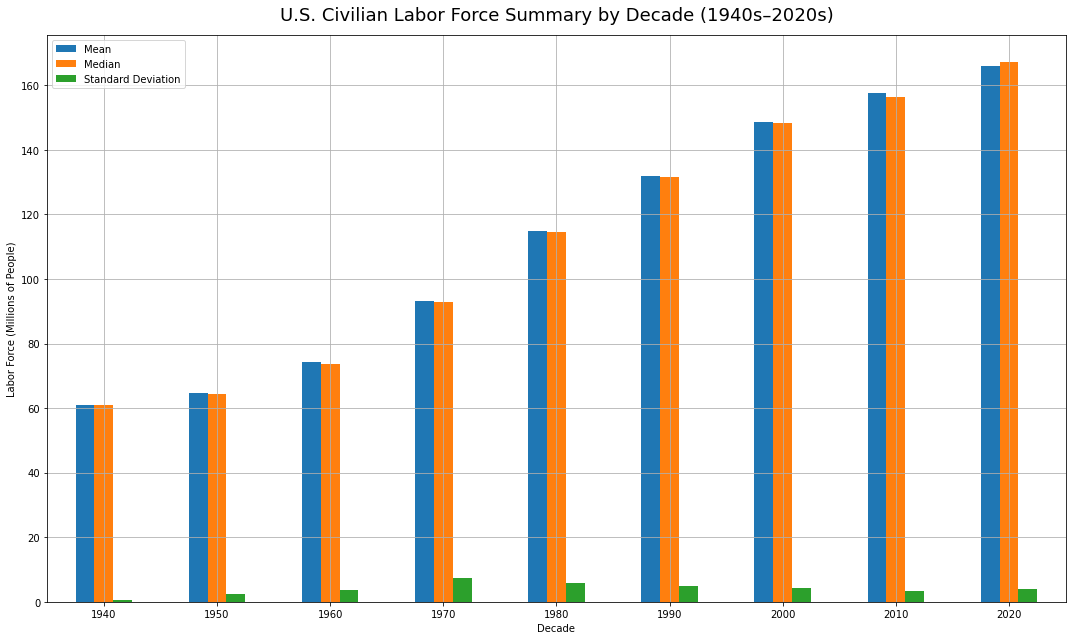

In [16]:
# Aggregate annual metrics by decade and scale values to millions for visualization
ax = (
    clf_df.groupby('Decade')['Annual']
        .agg(['mean', 'median', 'std'])
        .div(1e6)
        .plot.bar(
            figsize=(15,9),           
            grid=True,
            linewidth=2,
            rot=0
        )
)

ax.set_title(
    "U.S. Civilian Labor Force Summary by Decade (1940s–2020s)", fontsize=18, pad=15
)
ax.set_xlabel('Decade')
ax.set_ylabel('Labor Force (Millions of People)')
ax.legend(['Mean', 'Median', 'Standard Deviation'])

plt.tight_layout()
plt.show()

10. Use `Markdown` syntax to write a short paragraph (3-5 sentences) describing your process for completing this assignment.

Where did you start? Did you run into any issues? How did you solve them? Did you learn anything new? Include anything you think is relevant.


I started this project by downloading the Civilian Labor Force data from the BLS website and loading it into Pandas. 

I had an issue with data types because some monthly columns were `object` instead of numbers. I found out this happened because of footnotes like `(1)`, `(9)`, `(12)`, extra spaces, and dashes (`-`) used for missing data during the September 2025 lockdown and late 2026. 

To clean the data, I used regular expressions with `replace(r'\(\d+\)', '', regex=True)` to remove all footnote numbers and brackets. Then, I used `pd.to_numeric()` with `errors='coerce'`, which automatically converted dashes and missing values into `NaN` and changed the columns to `float64` (since standard `int64` cannot hold `NaN`). After that, I multiplied the monthly numbers by 1,000 as required by the assignment instructions. 

In this lab, I learned how regular expressions work for text cleaning and how Pandas manages indexes. I finally understood why a column disappears from `.columns` when it becomes an index, and why I need to reset the index before using `.groupby()` to calculate `mean`, `median`, and `std` for my chart.